# 실습 20: 얼마나 빗나갔나 (회귀)

설비 고장 기록으로 공정온도를 맞혀 본다

## Step 1. 데이터 확인

In [1]:
import pandas as pd

# 원본 불러오기
df = pd.read_csv("../../data/16_machine-failure.csv")

# 전체 행 수와 열 개수
print("행", df.shape[0], "/ 열", df.shape[1])

# 열 이름을 전부 출력
print("열 이름:", list(df.columns))

# 숫자로 된 열의 최소·최대·평균
숫자열 = df.select_dtypes(include="number").columns
print(df[숫자열].agg(["min", "max", "mean"]))

행 10000 / 열 7
열 이름: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']
      Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
min             295.30000                305.70000               1168.0000   
max             304.50000                313.80000               2886.0000   
mean            300.00493                310.00556               1538.7761   

      Torque [Nm]  Tool wear [min]  
min       3.80000            0.000  
max      76.60000          253.000  
mean     39.98691          107.951  


## Step 2. 맞힐 숫자 정하기

맞힐 것 : Process temperature [K] - 공정온도
왜 : 지금 조건에서 나와야 할 온도를 알면, 실제가 그보다 높을 때 이상 신호가 된다

### 문법 노트 - 회귀에서 새로 나오는 이름

| 쓴 것 | 하는 일 |
|---|---|
| mean_absolute_error | 평균 몇 만큼 빗나갔나 (MAE) |
| mean_squared_error | 제곱해서 평균 - 뿌리를 씌우면 RMSE |
| r2_score | 기준 모델 대비 얼마나 나은가 (R2) |
| LinearRegression | 숫자를 맞히는 모델 중 가장 단순한 것 |

## Step 3. 한 바퀴 돌리기

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ① 입력과 결과 열을 나눈다
입력열 = ["Air temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]
X = df[입력열]
y = df["Process temperature [K]"]

# ② 학습용·시험용을 8대 2로 나눈다
학습입력, 시험입력, 학습정답, 시험정답 = train_test_split(X, y, test_size=0.2, random_state=42)

# ③ 기준 모델 - 늘 학습용 평균값만 답한다
기준값 = 학습정답.mean()
기준예측 = pd.Series(기준값, index=시험정답.index)

# ④ 선형회귀 모델을 학습시킨다
모델 = LinearRegression()
모델.fit(학습입력, 학습정답)
예측 = 모델.predict(시험입력)

# ⑤ 기준 모델과 내 모델을 MAE·RMSE·R2로 비교한다
결과표 = pd.DataFrame(
    {
        "기준 모델": [
            mean_absolute_error(시험정답, 기준예측),
            mean_squared_error(시험정답, 기준예측) ** 0.5,
            r2_score(시험정답, 기준예측),
        ],
        "내 모델": [
            mean_absolute_error(시험정답, 예측),
            mean_squared_error(시험정답, 예측) ** 0.5,
            r2_score(시험정답, 예측),
        ],
    },
    index=["MAE", "RMSE", "R2"],
)
결과표


,기준 모델,내 모델
MAE,1.229517,0.595020
RMSE,1.472685,0.727922
R2,-0.000003,0.755684


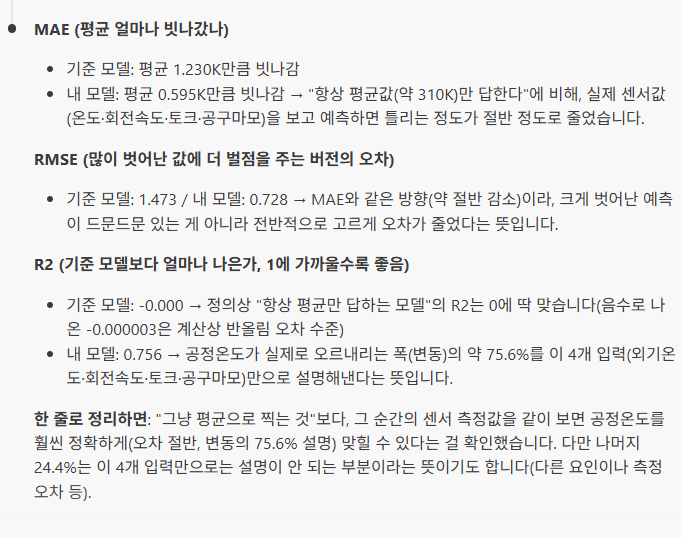

## Step 4. 무엇을 보고 맞혔나

Air temperature [K]       1.304745
Torque [Nm]               0.024444
Rotational speed [rpm]    0.017912
Tool wear [min]           0.004164
dtype: float64


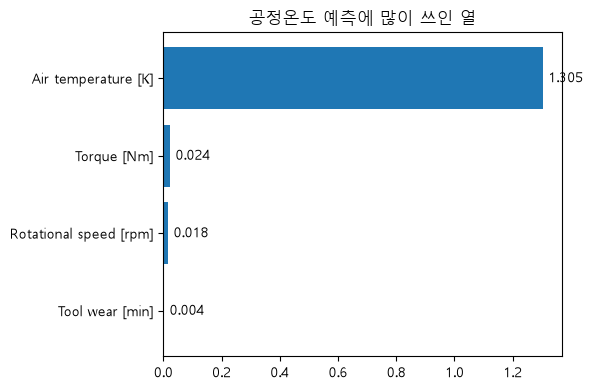

In [3]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 한글 깨짐 방지 - 그래프를 그리기 전에 폰트부터 잡는다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 앞 모델(모델)은 입력을 표준화하지 않아서, 열끼리 값의 크기(rpm 수천 대 온도 수백)가 달라
# 계수 크기를 그대로 비교하면 안 된다. 그래서 표준화한 새 모델을 따로 하나 더 학습시켜 중요도만 본다
표준화모델 = make_pipeline(StandardScaler(), LinearRegression())
표준화모델.fit(학습입력, 학습정답)

중요도 = pd.Series(
    표준화모델.named_steps["linearregression"].coef_, index=입력열
).abs().sort_values(ascending=False)
print(중요도)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(중요도.index[::-1], 중요도.values[::-1])
ax.set_title("공정온도 예측에 많이 쓰인 열")
for i, v in enumerate(중요도.values[::-1]):
    ax.text(v, i, f" {v:.3f}", va="center")

plt.tight_layout()
plt.show()


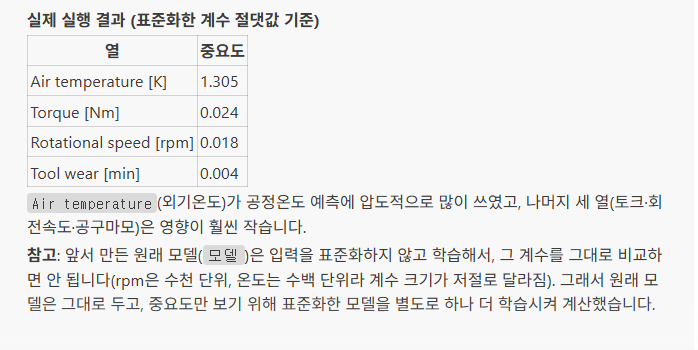

---
## 직접 해보기 (도전) - 대상을 바꾸면 자도 바뀐다

- 상황: 공정온도는 잘 맞혔는데, 다른 값도 같은 방식으로 되나
- 할 일: 맞히는 대상을 토크로 바꿔 한 번 더 돌리고 두 결과를 나란히 놓는다
- 결과물: 여섯 칸짜리 비교표 1개

In [4]:
# ① 이번엔 Torque [Nm]을 맞힌다 - 입력과 결과 열을 나눈다
입력열_토크 = ["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Tool wear [min]"]
X_토크 = df[입력열_토크]
y_토크 = df["Torque [Nm]"]

# ② 학습용·시험용을 8대 2로 나눈다
학습입력_토크, 시험입력_토크, 학습정답_토크, 시험정답_토크 = train_test_split(X_토크, y_토크, test_size=0.2, random_state=42)

# ③ 선형회귀 모델을 학습시킨다
모델_토크 = LinearRegression()
모델_토크.fit(학습입력_토크, 학습정답_토크)
예측_토크 = 모델_토크.predict(시험입력_토크)

# ④ 방금과 같은 방식으로 MAE·RMSE·R2를 구한다
MAE_토크 = mean_absolute_error(시험정답_토크, 예측_토크)
RMSE_토크 = mean_squared_error(시험정답_토크, 예측_토크) ** 0.5
R2_토크 = r2_score(시험정답_토크, 예측_토크)

# ⑤ 공정온도(내 모델)와 토크 결과를 나란히 놓는다
비교표 = pd.DataFrame(
    {
        "공정온도": [결과표.loc["MAE", "내 모델"], 결과표.loc["RMSE", "내 모델"], 결과표.loc["R2", "내 모델"]],
        "토크": [MAE_토크, RMSE_토크, R2_토크],
    },
    index=["MAE", "RMSE", "R2"],
)
비교표


,공정온도,토크
MAE,0.595020,3.686211
RMSE,0.727922,4.897887
R2,0.755684,0.756591


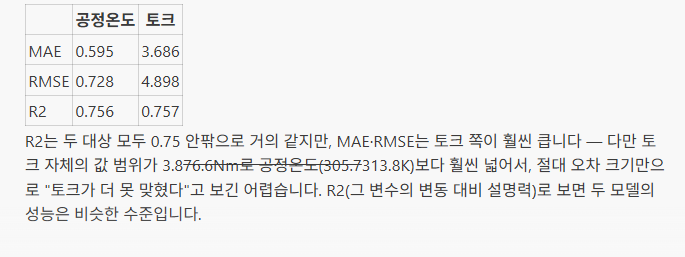

# 실습 22 - 결과 그림 세 장

## Step 1. 그림 1 - 무엇을 보고 판단했나

Air temperature [K]       1.304745
Torque [Nm]               0.024444
Rotational speed [rpm]    0.017912
Tool wear [min]           0.004164
dtype: float64


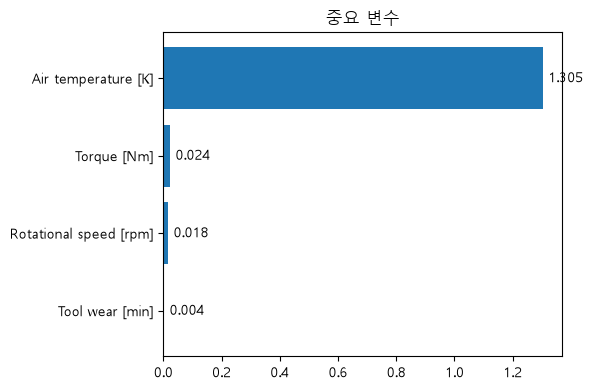

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# 한글 깨짐 방지 - 그래프를 그리기 전에 폰트부터 잡는다
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 표준화모델(공정온도를 맞히는 선형회귀, 계수를 비교하려고 입력을 표준화해서 학습시킨 모델)의 계수 절댓값을 열별 중요도로 보고, 위에서부터 10개만 뽑는다
중요도 = pd.Series(
    표준화모델.named_steps["linearregression"].coef_, index=입력열
).abs().sort_values(ascending=False)
상위10 = 중요도.head(10)
print(상위10)

# results 폴더를 만든다
os.makedirs("results", exist_ok=True)

# 가로 막대로 그리고, 제목은 "중요 변수", 막대 옆에 값도 적는다
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(상위10.index[::-1], 상위10.values[::-1])
ax.set_title("중요 변수")
for i, v in enumerate(상위10.values[::-1]):
    ax.text(v, i, f" {v:.3f}", va="center")

plt.tight_layout()
plt.savefig("results/fig1_importance.png", dpi=150)
plt.show()


### 그림 1 요약 - 무엇을 보고 판단했나

- 자세한 설명 : 표준화된 계수의 절댓값은, 입력 열들을 같은 자(평균 0, 표준편차 1)로 맞춘 뒤 선형회귀가 각 열에 매긴 가중치의 크기다. 값이 클수록 그 열이 조금만 바뀌어도 예측값(공정온도)이 크게 움직인다는 뜻이고, 늘고 주는 방향(양수/음수)이 아니라 크기만 본다. 실제로 재보니 Air temperature [K](외기온도)가 1.305로 나머지 세 열을 크게 앞섰고, Torque [Nm](0.024)·Rotational speed [rpm](0.018)·Tool wear [min](0.004)는 그보다 훨씬 작다. 즉 이 회귀 모델은 사실상 외기온도 하나에 거의 의존해서 공정온도를 맞히고 있고, 나머지 세 열은 미세한 조정 정도의 역할만 한다
- 한 줄 요약 : 공정온도 예측은 거의 전적으로 외기온도(Air temperature)에 좌우되며, 토크·회전속도·공구마모의 영향은 매우 작다